<a href="https://colab.research.google.com/github/Woramet-su/openapi/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
!pip -q install ultralytics gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 8.1 MB/s eta 0:00:00


In [2]:
import ultralytics, torch
ultralytics.checks()
print('มีการ์ดจอให้ใช้ไหม', torch.cuda.is_available())

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.7/107.7 GB disk)
มีการ์ดจอให้ใช้ไหม False


In [3]:
import os, glob
ROOT = '/content/lpr'
FILE_ID = '1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt'      # รหัสของ lpr-week12-data.zip บน Google Drive ของอาจารย์
if not os.path.exists(f'{ROOT}/gate'):
    !gdown {FILE_ID} -O /content/lpr-week12-data.zip
    !unzip -q /content/lpr-week12-data.zip -d {ROOT}
for s in ['train', 'val', 'test']:
    print(f'gate/{s}', len(glob.glob(f'{ROOT}/gate/{s}/images/*')), 'ภาพ')
print('road', len(glob.glob(f'{ROOT}/road/images/*')), 'เฟรม')
print(open(f'{ROOT}/README.txt', encoding='utf-8').read())

Downloading...
From (original): https://drive.google.com/uc?id=1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt
From (redirected): https://drive.google.com/uc?id=1-ZXdR3FtlZn_u1Mqf9qJ3pOnhYEgurAt&confirm=t&uuid=161dc889-badb-4381-9935-e172fcb3f3ea
To: /content/lpr-week12-data.zip
100% 90.8M/90.8M [00:01<00:00, 66.0MB/s]
gate/train 140 ภาพ
gate/val 30 ภาพ
gate/test 30 ภาพ
road 139 เฟรม
ชุดข้อมูลสำหรับใบงานแล็บสัปดาห์ที่ 12 วิชา Artificial Intelligence (520 331)
gate/  ภาพรถหน้าลานจอด 200 ใบ แบ่ง train 140 / val 30 / test 30
       ที่มา Thailand License Plates (ThailLand-plates) บน Roboflow Universe สัญญาอนุญาต CC BY 4.0
road/  เฟรมจากวิดีโอกล้องหน้ารถในกรุงเทพ 139 เฟรมที่มีเฉลย (416 ป้าย) ย่อเป็น 1920x1080
       ที่มา Thai License Plate Detector (Cytron) บน Roboflow Universe สัญญาอนุญาต CC BY 4.0
labels/ เป็นรูปแบบ YOLO (class cx cy w h หรือรูปหลายเหลี่ยม) มีคลาสเดียวคือ plate
ชื่อไฟล์ของ road มีเลขเฟรม เช่น 1_mp4-213_jpg... เลขนี้คือลำดับเวลาในวิดีโอ



In [4]:
import yaml, random, shutil, re
from PIL import Image

def make_yaml(name, train, val, test=None):
    """เขียนไฟล์บอก YOLO ว่าชุดฝึก ชุดตรวจ ชุดสอบ อยู่โฟลเดอร์ไหน (ใช้ path เต็ม)"""
    d = {'path': ROOT, 'train': train, 'val': val, 'names': {0: 'plate'}}
    if test: d['test'] = test
    p = f'{ROOT}/{name}.yaml'
    yaml.safe_dump(d, open(p, 'w'))
    return p

def read_boxes(label_path):
    """อ่านเฉลยหนึ่งไฟล์ คืนกรอบเป็น (cx, cy, w, h) สัดส่วนของภาพ รองรับทั้งกรอบและรูปหลายเหลี่ยม"""
    boxes = []
    for line in open(label_path):
        v = list(map(float, line.split()[1:]))
        if len(v) == 4:
            boxes.append(tuple(v))
        else:
            xs, ys = v[0::2], v[1::2]
            boxes.append(((min(xs)+max(xs))/2, (min(ys)+max(ys))/2, max(xs)-min(xs), max(ys)-min(ys)))
    return boxes

def label_of(img_path):
    return img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

def link_subset(src_imgs, dst):
    """สร้างโฟลเดอร์ชุดข้อมูลใหม่จากรายชื่อภาพ โดยคัดลอกทั้งภาพและเฉลย"""
    os.makedirs(f'{dst}/images', exist_ok=True); os.makedirs(f'{dst}/labels', exist_ok=True)
    for p in src_imgs:
        shutil.copy(p, f'{dst}/images/'); shutil.copy(label_of(p), f'{dst}/labels/')
    return dst

gate_yaml = make_yaml('gate', 'gate/train/images', 'gate/val/images', 'gate/test/images')
print(open(gate_yaml).read())

names:
  0: plate
path: /content/lpr
test: gate/test/images
train: gate/train/images
val: gate/val/images



In [5]:
from ultralytics import YOLO
from collections import Counter
coco = YOLO('yolov8n.pt')                       # สมองที่ฝึกกับ COCO มาแล้ว ดาวน์โหลดอัตโนมัติ
test_imgs = sorted(glob.glob(f'{ROOT}/gate/test/images/*'))
results = coco.predict(test_imgs, imgsz=640, conf=0.25, verbose=False)
count = Counter(coco.names[int(c)] for r in results for c in r.boxes.cls)
print('กรอบที่ตีได้ทั้งหมด', sum(count.values()))
print(count)
print('มีคำว่า license plate ในพจนานุกรม 80 คำไหม', any('plate' in n for n in coco.names.values()))

กรอบที่ตีได้ทั้งหมด 62
Counter({'car': 40, 'truck': 14, 'motorcycle': 2, 'person': 2, 'bus': 2, 'potted plant': 1, 'bicycle': 1})
มีคำว่า license plate ในพจนานุกรม 80 คำไหม False


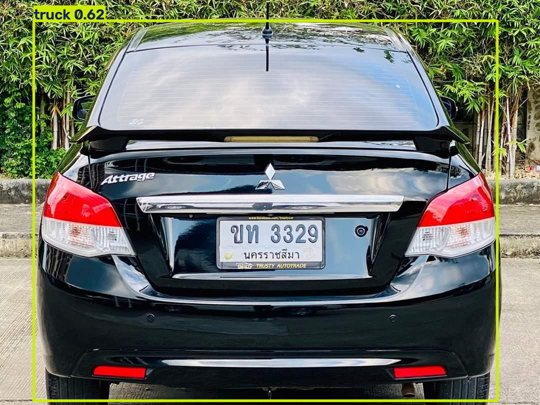

In [6]:
from IPython.display import display
display(Image.fromarray(results[10].plot()[:, :, ::-1]).resize((540, 405)))


In [7]:
import numpy as np
widths = []
for p in glob.glob(f'{ROOT}/gate/train/images/*'):
    for cx, cy, w, h in read_boxes(label_of(p)):
        widths.append(w)
widths = np.array(widths) * 100
print('ป้ายในชุดฝึก', len(widths), 'ใบ')
print('กว้างกลางๆ %.1f%% ของภาพ  เล็กสุด %.1f%%  ใหญ่สุด %.1f%%' % (np.median(widths), widths.min(), widths.max()))

ป้ายในชุดฝึก 141 ใบ
กว้างกลางๆ 14.3% ของภาพ  เล็กสุด 5.3%  ใหญ่สุด 25.4%


In [10]:
ft = YOLO('yolov8n.pt')
ft.train(data=gate_yaml, epochs=10, imgsz=100, batch=8, seed=0,
         project=f'{ROOT}/runs', name='finetune', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=None, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee5f0a58d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

รอบแรก 1  รอบที่ 7 77  รอบสุดท้าย 92.9


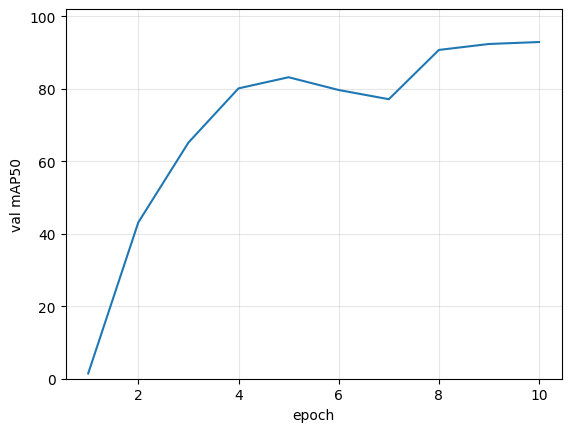

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def curve(run):
    df = pd.read_csv(f'{ROOT}/runs/{run}/results.csv')
    df.columns = [c.strip() for c in df.columns]
    return df['metrics/mAP50(B)'].values * 100

m = curve('finetune')
print('รอบแรก %.0f  รอบที่ 7 %.0f  รอบสุดท้าย %.1f' % (m[0], m[6], m[-1]))
plt.plot(range(1, len(m)+1), m); plt.xlabel('epoch'); plt.ylabel('val mAP50'); plt.ylim(0, 102); plt.grid(alpha=.3); plt.show()

In [12]:
def score(weights, data, split='val'):
    r = YOLO(weights).val(data=data, split=split, imgsz=640, batch=8, plots=False, verbose=False)
    return r.box.map50 * 100, r.box.map * 100

ft_test = score(f'{ROOT}/runs/finetune/weights/best.pt', gate_yaml, 'test')
print('ชุดสอบ  mAP50 %.1f   mAP50-95 %.1f' % ft_test)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 631.7±128.8 MB/s, size: 170.2 KB)
val: Scanning /content/lpr/gate/test/labels... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 1.4Kit/s 0.0s
val: New cache created: /content/lpr/gate/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4s/it 5.5s
                   all         30         30    0.00289     0.0333   0.000499   0.000105
Speed: 1.7ms preprocess, 151.8ms inference, 0.0ms loss, 17.9ms postprocess per image
ช

In [14]:
scratch = YOLO('yolov8n.yaml')                  # โครงสร้างเดียวกัน แต่น้ำหนักเริ่มจากค่าสุ่ม
scratch.train(data=gate_yaml, epochs=10, imgsz=100, batch=8, seed=0, pretrained=False,
              project=f'{ROOT}/runs', name='scratch', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scratch, nbs=64, nms=None, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee478b3bd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [15]:
frozen = YOLO('yolov8n.pt')
frozen.train(data=gate_yaml, epochs=10, imgsz=100, batch=8, seed=0, freeze=10,   # ล็อก 10 ชั้นแรก คือส่วนตา
             project=f'{ROOT}/runs', name='frozen', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=frozen, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee4e8d3f50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2086.5±496.7 MB/s, size: 170.2 KB)
val: Scanning /content/lpr/gate/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 7.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5s/it 5.8s
                   all         30         30    0.00148      0.433    0.00112   0.000307
Speed: 1.5ms preprocess, 176.4ms inference, 0.0ms loss, 5.1ms postprocess per image
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu

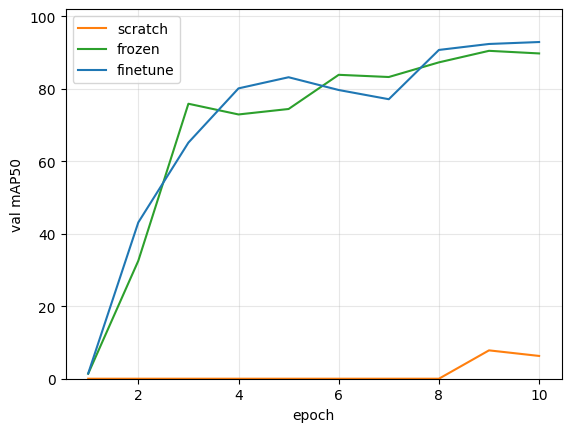

In [16]:
rows = []
for run, label in [('scratch', 'เริ่มจากศูนย์'), ('frozen', 'ยืมตาแล้วตรึง'), ('finetune', 'ยืมตาแล้วปรับทั้งตัว')]:
    m50, m5095 = score(f'{ROOT}/runs/{run}/weights/best.pt', gate_yaml, 'test')
    c = curve(run)
    stable = next((i + 1 for i in range(len(c)) if (c[i:] >= 94).all()), None)   # รอบแรกที่ยืนเหนือ 94 ได้ถาวร
    rows.append((label, c[0], '-' if stable is None else str(stable), m50, m5095))
print('%-22s %8s %12s %10s %10s' % ('วิธี', 'รอบแรก', 'ยืนเหนือ 94', 'mAP50', 'mAP50-95'))
for r in rows:
    print('%-22s %8.0f %12s %10.1f %10.1f' % r)
for run, c in [('scratch', 'tab:orange'), ('frozen', 'tab:green'), ('finetune', 'tab:blue')]:
    m = curve(run); plt.plot(range(1, len(m)+1), m, color=c, label=run)
plt.xlabel('epoch'); plt.ylabel('val mAP50'); plt.ylim(0, 102); plt.grid(alpha=.3); plt.legend(); plt.show()


In [18]:
random.seed(2569)
pick = random.sample(sorted(glob.glob(f'{ROOT}/gate/train/images/*')), 20)
link_subset(pick, f'{ROOT}/gate20/train')
gate20_yaml = make_yaml('gate20', 'gate20/train/images', 'gate/val/images', 'gate/test/images')
few = YOLO('yolov8n.pt')
few.train(data=gate20_yaml, epochs=10, imgsz=300, batch=8, seed=0,
          project=f'{ROOT}/runs', name='few20', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate20.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=300, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=few20, nbs=64, nms=None, opset=None, optimize=False, optimizer=aut

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee473d18d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [19]:
print('20 ใบ   ชุดสอบ mAP50 %.1f   mAP50-95 %.1f' % score(f'{ROOT}/runs/few20/weights/best.pt', gate_yaml, 'test'))
print('140 ใบ  ชุดสอบ mAP50 %.1f   mAP50-95 %.1f' % ft_test)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2147.8±387.0 MB/s, size: 164.1 KB)
val: Scanning /content/lpr/gate/test/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 6.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 30. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4s/it 5.6s
                   all         30         30    0.00333          1      0.255       0.14
Speed: 1.5ms preprocess, 158.0ms inference, 0.0ms loss, 15.5ms postprocess per image
20 ใบ   ชุดสอบ mAP50 25.5   mAP50-95 14.0
140 ใบ  ชุดส

In [20]:
road_yaml = make_yaml('road', 'road/images', 'road/images')
road_all = score(f'{ROOT}/runs/finetune/weights/best.pt', road_yaml)
print('หน้าลานจอด mAP50 %.1f   บนถนน mAP50 %.1f' % (ft_test[0], road_all[0]))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1370.6±1042.1 MB/s, size: 406.3 KB)
val: Scanning /content/lpr/road/labels... 139 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 1.5Kit/s 0.1s
val: New cache created: /content/lpr/road/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.4s/it 25.3s
                   all        139        416      0.413      0.204      0.182     0.0599
Speed: 1.2ms preprocess, 145.7ms inference, 0.0ms loss, 14.9ms postprocess per image
หน้าลานจอด mAP50 0.0   บนถนน mAP50 18.2


In [21]:
def iou(a, b):
    ix = max(0, min(a[2], b[2]) - max(a[0], b[0])); iy = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = ix * iy
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter)

model = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')
found, missed = [], []
for p in sorted(glob.glob(f'{ROOT}/road/images/*')):
    W, H = Image.open(p).size
    dets = [[float(v) for v in b] for b in model.predict(p, imgsz=640, conf=0.25, verbose=False)[0].boxes.xyxy]
    for cx, cy, w, h in read_boxes(label_of(p)):
        g = [(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H]
        (found if any(iou(d, g) >= 0.5 for d in dets) else missed).append(w * 100)
print('ป้ายทั้งหมด', len(found)+len(missed), 'ใบ  หาเจอ', len(found), 'ใบ')
print('ความกว้างกลางๆ ของป้ายที่เจอ %.1f%%  ที่พลาด %.1f%%' % (np.median(found), np.median(missed)))
for lo, hi in [(0, 1), (1, 2), (2, 3), (3, 5), (5, 100)]:
    f = sum(lo <= x < hi for x in found); m = sum(lo <= x < hi for x in missed)
    print('ป้ายกว้าง %2d-%-3d%%  ทั้งหมด %3d  เจอ %2d' % (lo, hi, f+m, f))

ป้ายทั้งหมด 416 ใบ  หาเจอ 95 ใบ
ความกว้างกลางๆ ของป้ายที่เจอ 4.3%  ที่พลาด 1.9%
ป้ายกว้าง  0-1  %  ทั้งหมด  23  เจอ  0
ป้ายกว้าง  1-2  %  ทั้งหมด 149  เจอ  1
ป้ายกว้าง  2-3  %  ทั้งหมด  81  เจอ 13
ป้ายกว้าง  3-5  %  ทั้งหมด 102  เจอ 49
ป้ายกว้าง  5-100%  ทั้งหมด  61  เจอ 32


In [22]:
frame_no = lambda p: int(re.search(r'-(\d+)_jpg', p).group(1))
road_imgs = sorted(glob.glob(f'{ROOT}/road/images/*'), key=frame_no)
early = [p for p in road_imgs if frame_no(p) < 213]
late  = [p for p in road_imgs if frame_no(p) >= 213]
link_subset(early, f'{ROOT}/road_time/train'); link_subset(late, f'{ROOT}/road_time/val')
road_time_yaml = make_yaml('road_time', 'road_time/train/images', 'road_time/val/images')
print('ชุดฝึก', len(early), 'เฟรม (เฟรมที่ %d ถึง %d)' % (frame_no(early[0]), frame_no(early[-1])))
print('ชุดตรวจ', len(late), 'เฟรม (เฟรมที่ %d ถึง %d)' % (frame_no(late[0]), frame_no(late[-1])))
print('ก่อนปรับ  ชุดตรวจบนถนน mAP50 %.1f' % score(f'{ROOT}/runs/finetune/weights/best.pt', road_time_yaml)[0])

ชุดฝึก 95 เฟรม (เฟรมที่ 3 ถึง 211)
ชุดตรวจ 44 เฟรม (เฟรมที่ 213 ถึง 307)
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1985.2±361.1 MB/s, size: 348.1 KB)
val: Scanning /content/lpr/road_time/val/labels... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 1.2Kit/s 0.0s
val: New cache created: /content/lpr/road_time/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.3s/it 7.5s
                   all         44        121      0.468      0.255      0.242     0.0793
Speed: 1.0ms preprocess, 134.4ms inference, 0.0ms loss, 16.7ms postprocess per image
ก่อนปรับ  ชุดตรวจบนถนน mAP50 24.2


In [24]:
adapt = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')    # เริ่มจากสมองที่เก่งหน้าลานจอดแล้ว
adapt.train(data=road_time_yaml, epochs=10, imgsz=200, batch=8, seed=0,
            project=f'{ROOT}/runs', name='roadadapt', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/road_time.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=200, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/lpr/runs/finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadadapt, nbs=64, nms=None, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee4e825be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [25]:
w = f'{ROOT}/runs/roadadapt/weights/best.pt'
print('หลังปรับ  ชุดตรวจบนถนน mAP50 %.1f' % score(w, road_time_yaml)[0])
print('หลังปรับ  ชุดสอบหน้าลานจอด mAP50 %.1f   (ก่อนปรับ %.1f)' % (score(w, gate_yaml, 'test')[0], ft_test[0]))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3593.1±979.2 MB/s, size: 356.9 KB)
val: Scanning /content/lpr/road_time/val/labels.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 13.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.2s/it 7.3s
                   all         44        121    0.00275      0.264    0.00292   0.000405
Speed: 1.1ms preprocess, 114.9ms inference, 0.0ms loss, 35.2ms postprocess per image
หลังปรับ  ชุดตรวจบนถนน mAP50 0.3
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1955.9±408.1 MB/s, size: 162.3 KB)
val: Scanning /content/lpr/gate/tes

In [27]:
link_subset(glob.glob(f'{ROOT}/gate/train/images/*') + early, f'{ROOT}/mix/train')
mix_yaml = make_yaml('mix', 'mix/train/images', 'road_time/val/images')
mix = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')
mix.train(data=mix_yaml, epochs=10, imgsz=100, batch=8, seed=0,
          project=f'{ROOT}/runs', name='mix', exist_ok=True, plots=False, verbose=False)

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/mix.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/lpr/runs/finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mix, nbs=64, nms=None, opset=None, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eee5efc3620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [29]:
w = f'{ROOT}/runs/mix/weights/best.pt'
print('ซ้อมทวน  ชุดตรวจบนถนน mAP50 %.1f' % score(w, road_time_yaml)[0])
print('ซ้อมทวน  ชุดสอบหน้าลานจอด mAP50 %.1f' % score(w, gate_yaml, 'test')[0])

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2723.0±178.8 MB/s, size: 340.6 KB)
val: Scanning /content/lpr/road_time/val/labels.cache... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 1.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.0s/it 6.2s
                   all         44        121      0.452      0.314      0.279     0.0817
Speed: 1.0ms preprocess, 111.2ms inference, 0.0ms loss, 13.0ms postprocess per image
ซ้อมทวน  ชุดตรวจบนถนน mAP50 27.9
Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1957.2±358.5 MB/s, size: 207.0 KB)
val: Scanning /content/lpr/gate/test

In [28]:
hot = YOLO('yolov8n.pt')
hot.train(data=gate_yaml, epochs=10, imgsz=100, batch=8, seed=0,
          optimizer='SGD', lr0=0.1, warmup_epochs=0,        # ก้าวใหญ่ห้าสิบเท่า ไม่วอร์มอัพ
          project=f'{ROOT}/runs', name='hotlr', exist_ok=True, plots=False, verbose=False)
print('คะแนนชุดตรวจแต่ละรอบ', [round(x) for x in curve('hotlr')])
print('ชุดสอบหน้าลานจอด %.1f   บนถนน %.1f' % (score(f'{ROOT}/runs/hotlr/weights/best.pt', gate_yaml, 'test')[0],
                                             score(f'{ROOT}/runs/hotlr/weights/best.pt', road_yaml)[0]))

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/gate.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, kobj=1.0, line_width=None, lr0=0.1, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hotlr, nbs=64, nms=None, opset=None, optimize=False, optimizer=SGD, o

In [31]:
random.seed(2569)
shuffled = road_imgs[:]; random.shuffle(shuffled)
link_subset(shuffled[:len(early)], f'{ROOT}/road_rand/train'); link_subset(shuffled[len(early):], f'{ROOT}/road_rand/val')
road_rand_yaml = make_yaml('road_rand', 'road_rand/train/images', 'road_rand/val/images')
rnd = YOLO(f'{ROOT}/runs/finetune/weights/best.pt')
rnd.train(data=road_rand_yaml, epochs=10, imgsz=100, batch=8, seed=0,
          project=f'{ROOT}/runs', name='roadrand', exist_ok=True, plots=False, verbose=False)
print('สุ่มแบ่ง     ชุดตรวจของตัวเอง mAP50 %.1f' % score(f'{ROOT}/runs/roadrand/weights/best.pt', road_rand_yaml)[0])
print('แบ่งตามเวลา ชุดตรวจของตัวเอง mAP50 %.1f' % score(f'{ROOT}/runs/roadadapt/weights/best.pt', road_time_yaml)[0])
print('แบ่งตามเวลา สอบกับเฟรมที่เคยฝึก mAP50 %.1f' % score(f'{ROOT}/runs/roadadapt/weights/best.pt', road_time_yaml, 'train')[0])

Ultralytics 8.4.174 🚀 Python-3.13.16 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lpr/road_rand.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/lpr/runs/finetune/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roadrand, nbs=64, nms=None, ops

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

## Google Colab is available in VS Code!
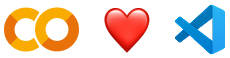

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  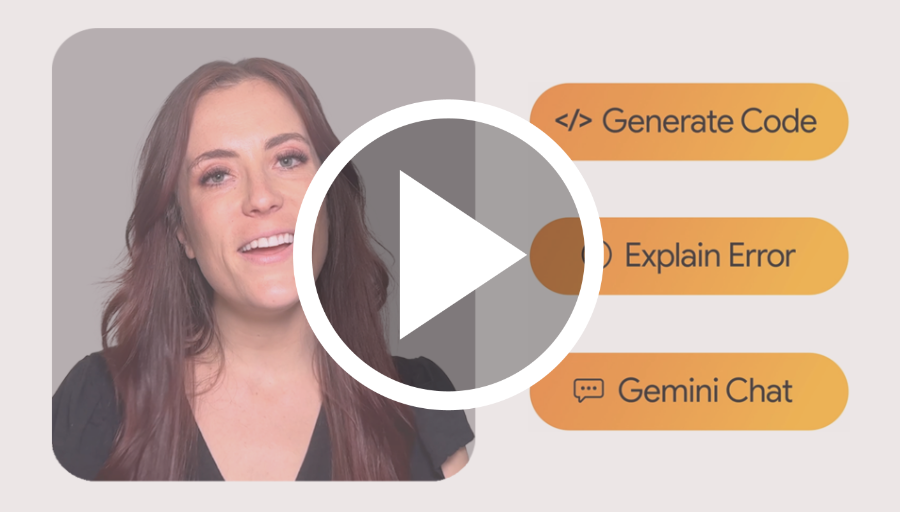
  </a>
</center>

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

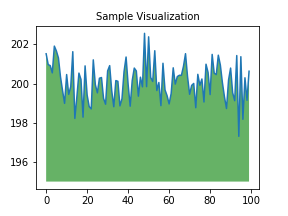

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
